In [2]:
import pandas as pd
import numpy as np
from sklearn import datasets
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.svm import SVC

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')
import os

path = r"C:\Users\Frans\koulu\AMK Tietojenkäsittely 2024-2025"

csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
full_path = os.path.join(path, csv_file)

df = pd.read_csv(full_path)
print(df.head())

   Destination Port  Flow Duration  Total Fwd Packets  \
0                22        1266342                 41   
1                22        1319353                 41   
2                22            160                  1   
3                22        1303488                 41   
4             35396             77                  1   

   Total Length of Fwd Packets  Fwd Packet Length Max  Fwd Packet Length Min  \
0                         2664                    456                      0   
1                         2664                    456                      0   
2                            0                      0                      0   
3                         2728                    456                      0   
4                            0                      0                      0   

   Fwd Packet Length Mean  Fwd Packet Length Std  Bwd Packet Length Max  \
0               64.975610             109.864573                    976   
1               64.975610 

In [3]:

df100k = df.sample(n=100000, random_state=42)
 
Valitut10 =[
'Init_Win_bytes_forward',
'Flow IAT Mean',
'Packet Length Std',
'Subflow Fwd Bytes',
'Flow Duration',
'Bwd Packet Length Mean',
'Total Length of Fwd Packets',
'PSH Flag Count',
'Flow Packets/s',
'Destination Port',
'Attack Type'
]

df_valitut = df100k[Valitut10]
print(df_valitut.head())

df_valitut.to_csv('karsittu_100k_sample.csv', index=False)

         Init_Win_bytes_forward  Flow IAT Mean  Packet Length Std  \
2469841                      -1   6.155400e+03          44.403453   
1288855                     274   7.210000e+02         136.541081   
817253                      256   5.626240e+06        1627.461760   
1260920                    8192   1.722652e+06        1026.224887   
1193007                   65535   2.756890e+04         544.924340   

         Subflow Fwd Bytes  Flow Duration  Bwd Packet Length Mean  \
2469841                124          30777              122.000000   
1288855                 53           2884              341.000000   
817253                  56       73141122             1934.500000   
1260920                845      115417660             1216.111111   
1193007               1204         551378              613.500000   

         Total Length of Fwd Packets  PSH Flag Count  Flow Packets/s  \
2469841                          124               0      194.950775   
1288855                   

In [18]:
Valitut10.head()

AttributeError: 'list' object has no attribute 'head'

In [3]:
df_valitut.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100000 entries, 2469841 to 2155658
Data columns (total 11 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Init_Win_bytes_forward       100000 non-null  int64  
 1   Flow IAT Mean                100000 non-null  float64
 2   Packet Length Std            100000 non-null  float64
 3   Subflow Fwd Bytes            100000 non-null  int64  
 4   Flow Duration                100000 non-null  int64  
 5   Bwd Packet Length Mean       100000 non-null  float64
 6   Total Length of Fwd Packets  100000 non-null  int64  
 7   PSH Flag Count               100000 non-null  int64  
 8   Flow Packets/s               100000 non-null  float64
 9   Destination Port             100000 non-null  int64  
 10  Attack Type                  100000 non-null  object 
dtypes: float64(4), int64(6), object(1)
memory usage: 9.2+ MB


In [4]:
X = df_valitut.drop('Attack Type', axis=1)
y = df_valitut['Attack Type']


X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

print(f"Opetusdatan (Train) koko: {X_train.shape[0]} riviä ({X_train.shape[0]/len(df_valitut)*100}%)")
print(f"Validointidatan (Validation) koko: {X_val.shape[0]} riviä ({X_val.shape[0]/len(df_valitut)*100}%)")
print(f"Testidatan (Test) koko: {X_test.shape[0]} riviä ({X_test.shape[0]/len(df_valitut)*100}%)")

Opetusdatan (Train) koko: 60000 riviä (60.0%)
Validointidatan (Validation) koko: 20000 riviä (20.0%)
Testidatan (Test) koko: 20000 riviä (20.0%)


In [6]:
# Huom: Vaatii imbalanced-learn -kirjaston asennuksen (pip install imbalanced-learn)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier


# 1. Määritellään putken vaiheet. 
# Tehtävänanto kehotti pohtimaan järjestystä: skaalataanko ensin ja sitten SMOTE, vai toisinpäin?
putki = ImbPipeline([
    ('skaalaus', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('malli', KNeighborsClassifier())
])

# 2. Määritellään testattavat hyperparametrit (GridSearch)
# Kokeillaan esim. eri naapureiden määriä kNN:lle
parametrit = {
    'malli__n_neighbors': [3, 5, 7],
    # Voit myös testata putken vaiheita täällä! Esimerkiksi StandardScaler vs MinMaxScaler.
}

# 3. Luodaan GridSearchCV-olio
grid_search = GridSearchCV(putki, parametrit, cv=3, scoring='accuracy', n_jobs=-1)

# 4. Koulutetaan malli (Tämä vaihe voi kestää hetken!)
grid_search.fit(X_train, y_train)

,estimator,Pipeline(step...lassifier())])
,param_grid,"{'malli__n_neighbors': [3, 5, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [7]:

# 1. Rakennetaan putki (Pipeline)
# Järjestys: Ensin skaalaus, sitten harvinaisten hyökkäyksien lisäys (SMOTE), ja lopuksi malli.
rf_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(random_state=42))
])

# 2. Määritellään hyperparametrien testiverkko (Grid)
# Kokeillaan "suunnilleen hyviä" aloitusarvoja, jotta kone ei mene heti jumiin.
param_grid = {
    'rf__n_estimators': [50, 100],        # Kokeillaan 50 ja 100 puun metsää
    'rf__max_depth': [None, 10, 20],      # Ei rajoitusta, 10 tai 20 kysymyksen maksimisyvyys
    
    # PRO-VINKKI: Tehtävänannossa käskettiin kokeilemaan tuloksia ilman SMOTEa ja sen kanssa.
    # GridSearchCV voi testata sen puolestanne, jos otatte alla olevan rivin käyttöön!
    #'smote': ['passthrough', SMOTE(random_state=42)] 
}

# 3. Asetetaan GridSearchCV
# cv=3 tarkoittaa 3-osaista ristiinvalidointia.
# n_jobs=-1 on TODELLA TÄRKEÄ: se käskee konetta käyttämään kaikkia suorittimen ytimiä, mikä nopeuttaa koulutusta huomattavasti!
grid_search_rf = GridSearchCV(rf_pipeline, param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=2)

# 4. Käynnistetään mallin koulutus ja haku
# Huom: Tässä saattaa mennä hetki! verbose=2 (yllä) tulostaa edistymistä näytölle.
print("Aloitetaan Random Forestin koulutus...")
grid_search_rf.fit(X_train, y_train) # Ota kommenttimerkki pois, kun olet valmis ajamaan

# 5. Tulostetaan parhaat löydökset (Ajetaan fit-vaiheen jälkeen)
print(f"Paras hyperparametriyhdistelmä: {grid_search_rf.best_params_}")

Aloitetaan Random Forestin koulutus...
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Paras hyperparametriyhdistelmä: {'rf__max_depth': None, 'rf__n_estimators': 100}


MALLIN TARKKUUS VALIDOINTIDATALLA: 99.39%

--- Luokitteluraportti (Classification Report) ---
                precision    recall  f1-score   support

          Bots       0.64      0.89      0.74        18
   Brute Force       0.99      1.00      0.99        75
          DDoS       1.00      1.00      1.00      1023
           DoS       0.99      0.99      0.99      1535
Normal Traffic       1.00      0.99      1.00     16616
 Port Scanning       0.99      1.00      0.99       715
   Web Attacks       0.14      0.67      0.23        18

      accuracy                           0.99     20000
     macro avg       0.82      0.93      0.85     20000
  weighted avg       1.00      0.99      1.00     20000



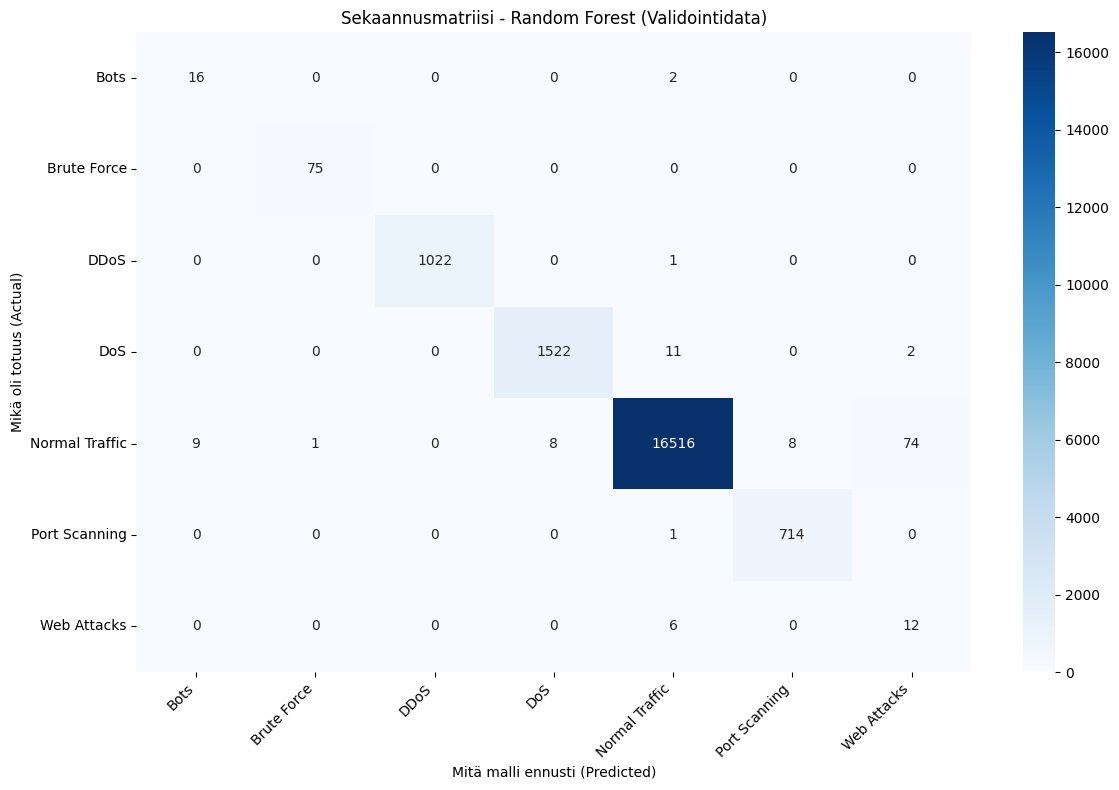

In [13]:
# 1. Otetaan paras malli talteen GridSearchista
best_rf_model = grid_search_rf.best_estimator_

# 2. Tehdään ennusteet VALIDointidatalla
y_val_pred = best_rf_model.predict(X_val)

# 3. Lasketaan ja tulostetaan yleinen tarkkuus
print(f"MALLIN TARKKUUS VALIDOINTIDATALLA: {accuracy_score(y_val, y_val_pred) * 100:.2f}%\n")

# 4. Tulostetaan tarkempi luokitteluraportti (sisältää Precision, Recall ja F1-Score)
print("--- Luokitteluraportti (Classification Report) ---")
print(classification_report(y_val, y_val_pred))

# 5. Piirretään sekaannusmatriisi (Confusion Matrix) lämpökarttana
cm = confusion_matrix(y_val, y_val_pred)

plt.figure(figsize=(12, 8))
# fmt='d' näyttää luvut kokonaislukuina, cmap muuttaa väriteemaa
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=best_rf_model.classes_, 
            yticklabels=best_rf_model.classes_)
plt.xlabel('Mitä malli ennusti (Predicted)')
plt.ylabel('Mikä oli totuus (Actual)')
plt.title('Sekaannusmatriisi - Random Forest (Validointidata)')
plt.xticks(rotation=45, ha='right') # Kääntää x-akselin tekstejä, jotta ne mahtuvat paremmin
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler


# 1. Rakennetaan putki. 
# 'scaler'-kohdassa on oletuksena StandardScaler, mutta GridSearch ylikirjoittaa sen testeissä.
rf_pipeline_scaler = ImbPipeline([
    ('scaler', StandardScaler()), 
    ('smote', SMOTE(random_state=42)),
    # Käytetään niitä hyviä asetuksia, jotka löysit aiemmin!
    ('rf', RandomForestClassifier(n_estimators=100,max_depth=20, random_state=42))
])



# 2. Määritellään testattavat skaalaimet
param_grid_scaler = {
    # Testataan kolme skenaariota: StandardScaler, MinMaxScaler ja "ei skaalausta" (passthrough)
    'scaler': [StandardScaler(), MinMaxScaler(), 'passthrough']
}

# 3. Asetetaan GridSearchCV. 
# Huom: scoring on nyt 'f1_macro', joten se ei tuijota sokeasti isointa (Normal Traffic) luokkaa!
grid_search_scaler = GridSearchCV(
    rf_pipeline_scaler, 
    param_grid_scaler, 
    cv=3, 
    scoring='f1_macro', 
    n_jobs=-1, 
    verbose=2
)

# 4. Koulutetaan (Tämä on paljon nopeampi kuin edellinen, koska malleja on vain 3)
print("Aloitetaan skaalaimien vertailu...")
grid_search_scaler.fit(X_train, y_train)

# 5. Tulostetaan tulokset
print("\n--- SKAALAUSTESTIN TULOKSET ---")
print(f"Paras skaalain f1_macro -mittarilla: {grid_search_scaler.best_params_['scaler']}")
print(f"Kaikki tulokset (f1_macro -keskiarvot):")

# Tulostetaan kunkin skaalaimen saamat pisteet selkeästi
for mean_score, params in zip(grid_search_scaler.cv_results_['mean_test_score'], grid_search_scaler.cv_results_['params']):
    # Jos skaalain on 'passthrough', nimetään se nätimmin tulostuksessa
    scaler_name = params['scaler'] if params['scaler'] != 'passthrough' else 'Ei skaalausta'
    print(f"{scaler_name}: {mean_score:.4f}")

Aloitetaan skaalaimien vertailu...
Fitting 3 folds for each of 3 candidates, totalling 9 fits

--- SKAALAUSTESTIN TULOKSET ---
Paras skaalain f1_macro -mittarilla: StandardScaler()
Kaikki tulokset (f1_macro -keskiarvot):
StandardScaler(): 0.8720
MinMaxScaler(): 0.8699
Ei skaalausta: 0.8700


In [16]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# 1. Rakennetaan putki.
# Järjestys on kriittinen: Skaalaus -> PCA -> SMOTE -> Malli
rf_pipeline_pca = ImbPipeline([
    ('scaler', StandardScaler()), 
    ('pca', PCA(random_state=42)), # Oletuksena PCA on mukana
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42))
])

# 2. Määritellään testattavat asiat (PCA:n komponenttien määrä)
param_grid_pca = {
    # Testataan kolme skenaariota: 5 komponenttia, 8 komponenttia ja "ei PCA:ta" (passthrough)
    'pca': [PCA(n_components=5, random_state=42), 
            PCA(n_components=8, random_state=42), 
            'passthrough']
}

# 3. Asetetaan GridSearchCV
grid_search_pca = GridSearchCV(
    rf_pipeline_pca, 
    param_grid_pca, 
    cv=3, 
    scoring='f1_macro', 
    n_jobs=-1, 
    verbose=2
)

# 4. Koulutetaan
print("Aloitetaan PCA:n testaus (5 komponenttia, 8 komponenttia ja ilman PCA:ta)...")
grid_search_pca.fit(X_train, y_train)

# 5. Tulostetaan tulokset
print("\n--- PCA-TESTIN TULOKSET ---")
print(f"Paras PCA-asetus f1_macro -mittarilla: {grid_search_pca.best_params_['pca']}")
print(f"Kaikki tulokset (f1_macro -keskiarvot):")

for mean_score, params in zip(grid_search_pca.cv_results_['mean_test_score'], grid_search_pca.cv_results_['params']):
    pca_name = f"PCA ({params['pca'].n_components} komponenttia)" if params['pca'] != 'passthrough' else 'Ei PCA:ta (kaikki 10 saraketta)'
    print(f"{pca_name}: {mean_score:.4f}")

Aloitetaan PCA:n testaus (5 komponenttia, 8 komponenttia ja ilman PCA:ta)...
Fitting 3 folds for each of 3 candidates, totalling 9 fits

--- PCA-TESTIN TULOKSET ---
Paras PCA-asetus f1_macro -mittarilla: passthrough
Kaikki tulokset (f1_macro -keskiarvot):
PCA (5 komponenttia): 0.7057
PCA (8 komponenttia): 0.7501
Ei PCA:ta (kaikki 10 saraketta): 0.8720


In [17]:
from sklearn.preprocessing import StandardScaler
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# 1. Putki: Skaalaus -> SMOTE -> Malli
rf_pipeline_depth = ImbPipeline([
    ('scaler', StandardScaler()), 
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42))
])

# 2. Testataan vain syvyyttä
param_grid_depth = {
    'rf__max_depth': [20, 25]
}

# 3. GridSearchCV
grid_search_depth = GridSearchCV(
    rf_pipeline_depth, 
    param_grid_depth, 
    cv=3, 
    scoring='f1_macro', # Käytetään edelleen tätä, jotta harvinaiset luokat huomioidaan
    n_jobs=-1, 
    verbose=2
)

# 4. Koulutetaan
print("Aloitetaan puun syvyyden testaus (20 vs 25)...")
grid_search_depth.fit(X_train, y_train)

# 5. Tulostetaan
print("\n--- SYVYYSTESTIN TULOKSET ---")
print(f"Paras max_depth: {grid_search_depth.best_params_['rf__max_depth']}")
for mean_score, params in zip(grid_search_depth.cv_results_['mean_test_score'], grid_search_depth.cv_results_['params']):
    print(f"Syvyys {params['rf__max_depth']}: {mean_score:.4f}")

Aloitetaan puun syvyyden testaus (20 vs 25)...
Fitting 3 folds for each of 2 candidates, totalling 6 fits

--- SYVYYSTESTIN TULOKSET ---
Paras max_depth: 20
Syvyys 20: 0.8720
Syvyys 25: 0.8710


Koulutetaan lopullista mallia (tässä saattaa mennä hetki)...

LOPULLISET TULOKSET TESTIDATALLA (X_test)

LOPULLINEN TARKKUUS (Accuracy): 99.28%

--- Luokitteluraportti (Classification Report) ---
                precision    recall  f1-score   support

          Bots       0.35      0.72      0.47        18
   Brute Force       0.97      0.99      0.98        75
          DDoS       1.00      1.00      1.00      1023
           DoS       0.99      0.99      0.99      1535
Normal Traffic       1.00      0.99      1.00     16616
 Port Scanning       0.99      1.00      1.00       715
   Web Attacks       0.14      0.67      0.23        18

      accuracy                           0.99     20000
     macro avg       0.78      0.91      0.81     20000
  weighted avg       1.00      0.99      0.99     20000



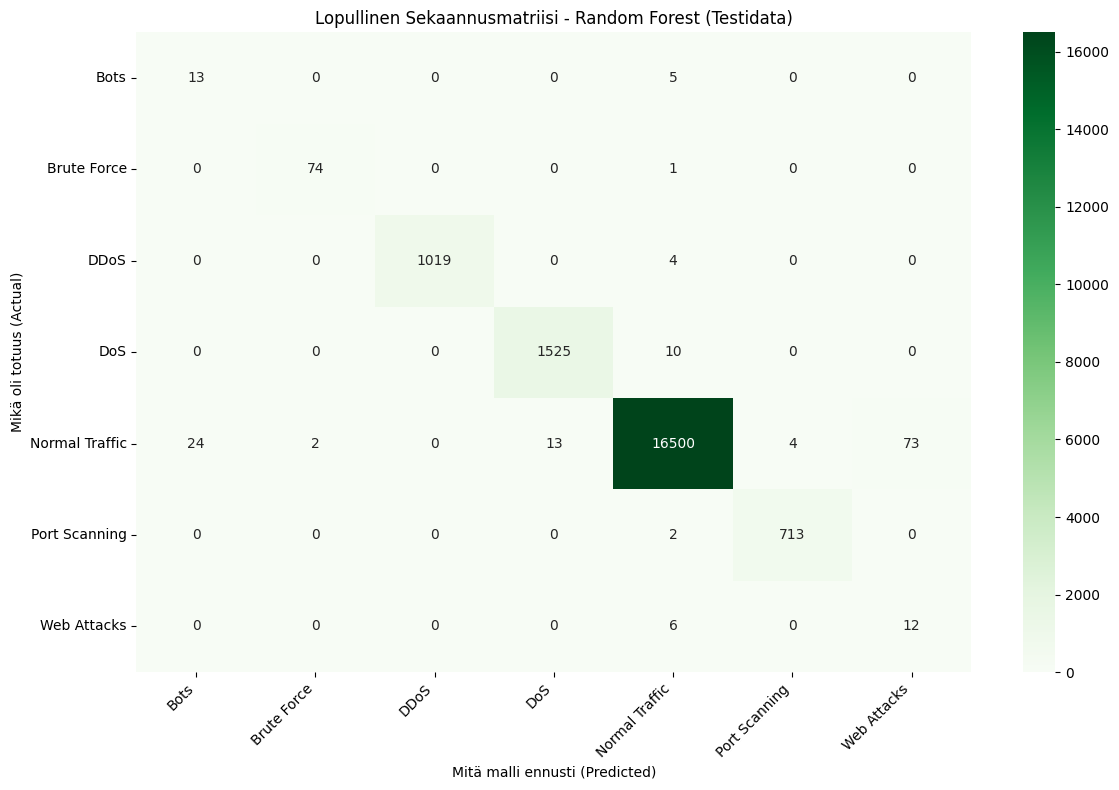

In [10]:
from sklearn.preprocessing import StandardScaler
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Rakennetaan lopullinen voittajaputki
final_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=100, max_depth=20, random_state=42, n_jobs=-1))
])

# 2. Koulutetaan malli kaikella mahdollisella oppimisdatalla (X_temp = Train + Val)
print("Koulutetaan lopullista mallia (tässä saattaa mennä hetki)...")
final_pipeline.fit(X_temp, y_temp)

# 3. Tehdään ennusteet TESTIdatalla, jota malli ei ole KOSKAAN aiemmin nähnyt
y_test_pred = final_pipeline.predict(X_test)

# 4. Tulostetaan lopulliset tulokset
print("\n" + "="*50)
print("LOPULLISET TULOKSET TESTIDATALLA (X_test)")
print("="*50)

print(f"\nLOPULLINEN TARKKUUS (Accuracy): {accuracy_score(y_test, y_test_pred) * 100:.2f}%\n")
print("--- Luokitteluraportti (Classification Report) ---")
print(classification_report(y_test, y_test_pred))

# 5. Piirretään sekaannusmatriisi
cm_final = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(12, 8))
sns.heatmap(cm_final, annot=True, fmt='d', cmap='Greens', # Vaihdetaan väri vihreäksi juhlan kunniaksi!
            xticklabels=final_pipeline.classes_, 
            yticklabels=final_pipeline.classes_)
plt.xlabel('Mitä malli ennusti (Predicted)')
plt.ylabel('Mikä oli totuus (Actual)')
plt.title('Lopullinen Sekaannusmatriisi - Random Forest (Testidata)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [12]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

# 1. Luodaan 5-osainen ristiinvalidointijako, joka säilyttää luokkien suhteet (stratified)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Lasketaan 5-osaista ristiinvalidoinnin tulosta lopulliselle mallille...")
print("(Tässä käytetään X_train_full ja y_train_full -dataa. Tämä voi kestää hetken.)")

# 2. Lasketaan ristiinvalidoinnin pisteet
# Käytämme putkea final_pipeline_rf, johon on jo tallennettu parhaat asetukset
cv_scores = cross_val_score(final_pipeline, X_train, y_train, cv=skf, scoring='accuracy', n_jobs=-1)

# 3. Tulostetaan tulokset
print("\n--- RISTIINVALIDOINNIN (CROSS-VALIDATION) TULOKSET ---")
print(f"Yksittäisten kierrosten tarkkuudet: {cv_scores}")
print(f"Keskimääräinen tarkkuus: {cv_scores.mean() * 100:.2f}%")
print(f"Keskihajonta (vaihtelu): {cv_scores.std() * 100:.4f}%")

Lasketaan 5-osaista ristiinvalidoinnin tulosta lopulliselle mallille...
(Tässä käytetään X_train_full ja y_train_full -dataa. Tämä voi kestää hetken.)

--- RISTIINVALIDOINNIN (CROSS-VALIDATION) TULOKSET ---
Yksittäisten kierrosten tarkkuudet: [0.99283333 0.99425    0.99508333 0.99241667 0.99308333]
Keskimääräinen tarkkuus: 99.35%
Keskihajonta (vaihtelu): 0.0985%
